In [2]:
# Cell 1. IMPROTING LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files
import io
import os

In [3]:
# Cell 2. LOADING DATASET

print("Please upload dataset (.csv, .xls, or .xlsx) below...")
target_column = "Species" # e.g., "species", "diagnosis", "status"
uploaded = files.upload()
file_path = next(iter(uploaded))
print(f"Successfully uploaded: {file_path}")
_, file_extension = os.path.splitext(file_path)

if file_extension.lower() == '.csv':
    df = pd.read_csv(file_path)
elif file_extension.lower() in ['.xls', '.xlsx']:
    try:
        engine_type = 'openpyxl' if file_extension.lower() == '.xlsx' else 'xlrd'
        df = pd.read_excel(file_path, engine=engine_type)
    except Exception:
        df = pd.read_csv(file_path)
        print(f"Note: '{file_path}' was successfully read as a CSV.")
else:
    raise ValueError("Unsupported file format! Please upload a .csv, .xls, or .xlsx file.")
class_names = df[target_column].unique().astype(str)
print("Data loaded and ready for training!")

Please upload dataset (.csv, .xls, or .xlsx) below...


Saving Iris.xls to Iris.xls
Successfully uploaded: Iris.xls
Note: 'Iris.xls' was successfully read as a CSV.
Data loaded and ready for training!


In [4]:
# Cell 3. DATA SPLITTING AND MODEL TRAINING
X = df.drop(columns=[target_column])
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining K-Nearest Neighbors model...")
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)


Training K-Nearest Neighbors model...


KNeighborsClassifier(n_neighbors=3)

Generating Data Distribution Diagram...


<Figure size 1000x800 with 0 Axes>

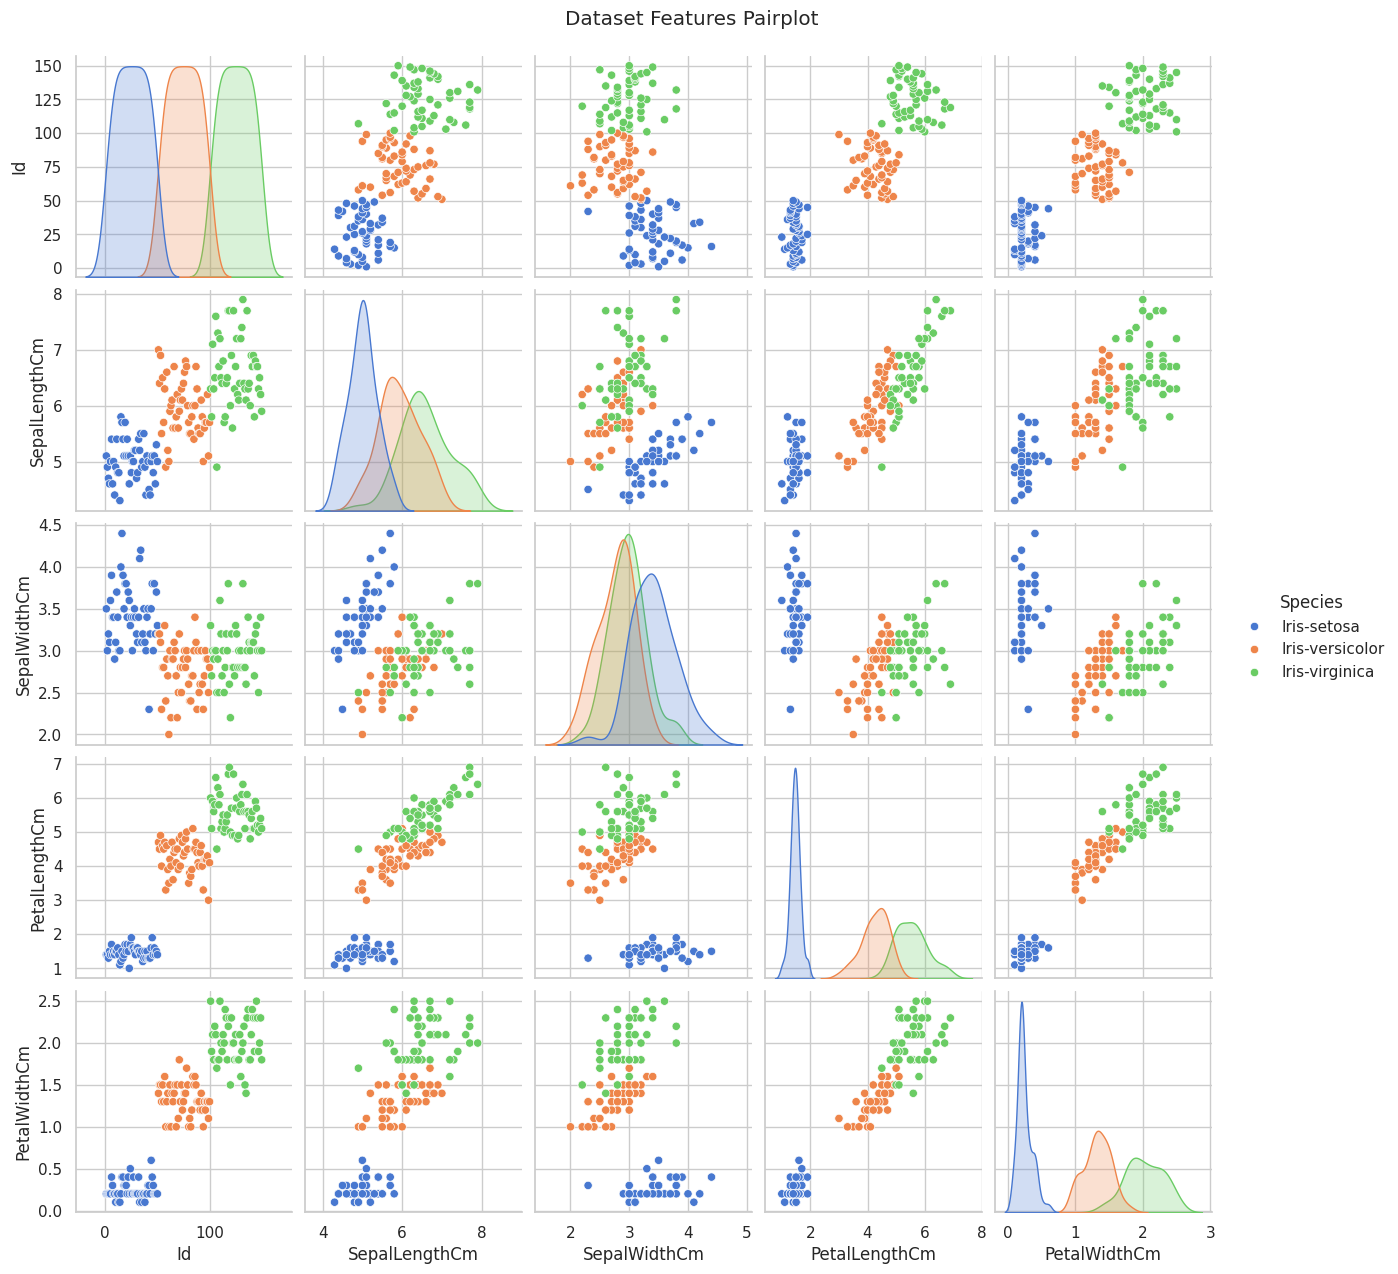

In [5]:
# Cell 4. EXPLORATORY DATA ANALYSIS (EDA) / DATA VISUALIZATION

print("Generating Data Distribution Diagram...")
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue=target_column)
plt.suptitle("Dataset Features Pairplot", y=1.02)
plt.show()

In [8]:
# Cell 5. MAKE PREDICTION AND EVALUATE

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"\n Model Accuracy: {accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, predictions, target_names=class_names))



 Model Accuracy: 100.00%

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Generating Confusion Matrix Diagram...


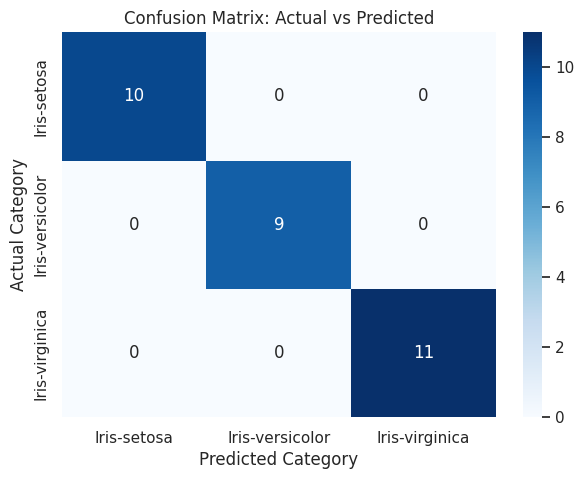

In [7]:
# Cell 6. VISUALIZING MODEL PERFORMATION
print("Generating Confusion Matrix Diagram...")
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()